# Dataset: Preço de casas

**Objetivo: **Implementar o primeiro modelo de ML e entender o fluxo básico.

**Instruções:**
1. Baixar o notebook exemplo
2. Executar o código de regressão linear (dataset de preço de casas)
3. Testar mudanças:

Alterar a proporção de treino/teste (ex: 70/30, 90/10)
Tentar um dataset diferente (se quiser)

4. **Responder no notebook:**

* Qual foi o valor do R2 obtido?
* O que esse valor significa?
* O que aconteceu quando você mudou a proporção de
treino/teste?

5. Subir o notebook respondido na pasta da semana 8 do repositório

In [ ]:
# Célula 1: Instalar e importar bibliotecas
!pip install kagglehub -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Bibliotecas instaladas e importadas!")

Bibliotecas instaladas e importadas!


Baixando dataset de casas de Melbourne...
Using Colab cache for faster access to the 'melbourne-housing-snapshot' dataset.
Dataset carregado! 13580 registros

 Primeiras linhas:
       Suburb           Address  Rooms Type      Price Method SellerG  \
0  Abbotsford      85 Turner St      2    h  1480000.0      S  Biggin   
1  Abbotsford   25 Bloomburg St      2    h  1035000.0      S  Biggin   
2  Abbotsford      5 Charles St      3    h  1465000.0     SP  Biggin   
3  Abbotsford  40 Federation La      3    h   850000.0     PI  Biggin   
4  Abbotsford       55a Park St      4    h  1600000.0     VB  Nelson   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
1  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
2  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   
3  4/03/2017       2.5    3067.0  ...       2.0  1.0      94.0 

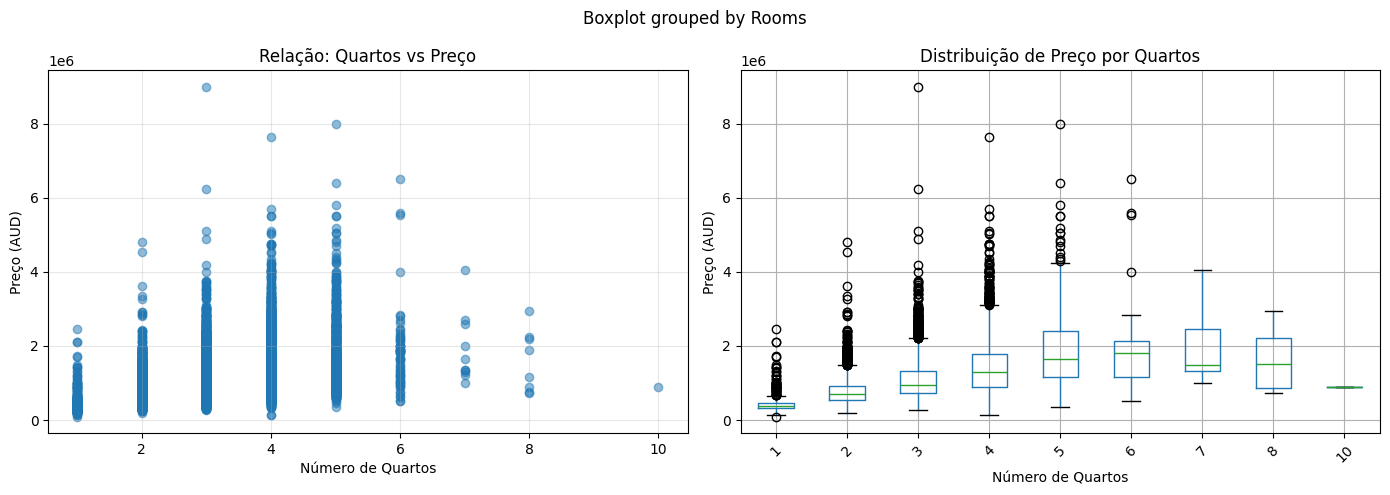

X shape: (13580, 1)
y shape: (13580,)

TESTANDO DIFERENTES PROPORÇÕES

📊 test_size = 0.1 (10% para teste):
   R² = 0.2517
   Equação: Preço = 330611.02 × Quartos + 104312.98

📊 test_size = 0.2 (20% para teste):
   R² = 0.2556
   Equação: Preço = 331067.71 × Quartos + 102941.12

📊 test_size = 0.3 (30% para teste):
   R² = 0.2430
   Equação: Preço = 330004.08 × Quartos + 103490.97

📊 test_size = 0.4 (40% para teste):
   R² = 0.2439
   Equação: Preço = 328894.82 × Quartos + 107263.11

RESUMO DOS RESULTADOS
 test_size  treino%  teste%       R²   coeficiente    intercepto
       0.1     90.0    10.0 0.251727 330611.018037 104312.979190
       0.2     80.0    20.0 0.255631 331067.706761 102941.120900
       0.3     70.0    30.0 0.243011 330004.079521 103490.965188
       0.4     60.0    40.0 0.243915 328894.819827 107263.107556


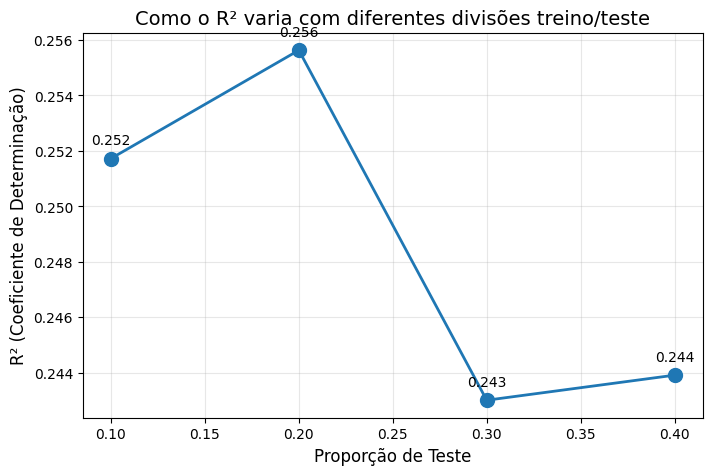


MODELO FINAL (80% treino / 20% teste)

📊 MÉTRICAS:
   R²: 0.2556
   RMSE: 543758.74 AUD
   MAE: 384558.01 AUD

📈 EQUAÇÃO DA RETA:
   Preço = 331067.71 × Quartos + 102941.12
   Significado: Cada quarto a mais aumenta o preço em R$ 331067.71 AUD


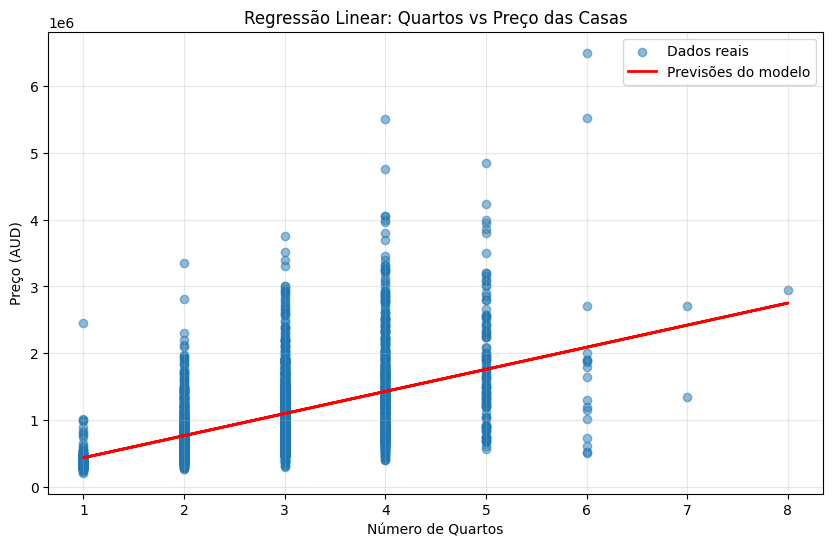


📝 RESPOSTAS PARA O TRABALHO

1️⃣ QUAL FOI O VALOR DO R² OBTIDO?
   R² ≈ 0.2556 (com 80/20)

2️⃣ O QUE ESSE VALOR SIGNIFICA?
   O R² de 0.2556 significa que 25.6% da variação 
   do preço das casas é explicada APENAS pelo número de quartos.
   Os outros 74.4% dependem de outros fatores (localização, 
   tamanho, ano, etc).

3️⃣ O QUE ACONTECEU QUANDO VOCÊ MUDOU A PROPORÇÃO?
   - Com mais dados de treino (teste=10%): R² = 0.2517
   - Com menos dados de treino (teste=40%): R² = 0.2439
   
   O R² variou porque o modelo aprende com diferentes amostras.
   Em dados reais, a estabilidade do R² indica se o modelo 
   é robusto.

4️⃣ POR QUE SEPARAR TREINO E TESTE É IMPORTANTE?
   ✅ Evita overfitting (modelo "decorar" os dados)
   ✅ Avalia se o modelo generaliza para novos dados
   ✅ Detecta se o modelo é útil na prática

5️⃣ CONCLUSÃO:
   Um modelo simples com apenas 1 variável (quartos) 
   explica apenas ~25.6% do preço. Para melhorar, 
   precisamos de mais variáveis (tamanho, localização

In [ ]:
# Semana 8 - Primeiro Modelo de Machine Learning
# Dataset REAL: Preço de Casas em Melbourne (Kaggle)

# Célula 2: Baixar dataset REAL de casas
import kagglehub

print("Baixando dataset de casas de Melbourne...")
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")
df = pd.read_csv(f"{path}/melb_data.csv")

print(f"Dataset carregado! {len(df)} registros")
print(f"\n Primeiras linhas:")
print(df.head())

# Célula 3: Explorar e limpar os dados
print(f"\n Colunas disponíveis:")
print(df.columns.tolist())

# Vamos usar 'Rooms' (número de quartos) para prever 'Price' (preço)
df_clean = df[['Rooms', 'Price']].dropna()
print(f"\n Após limpeza: {len(df_clean)} registros")

print(f"\n📈 Estatísticas:")
print(df_clean.describe())

# Célula 4: Visualizar os dados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1.scatter(df_clean['Rooms'], df_clean['Price'], alpha=0.5)
ax1.set_xlabel('Número de Quartos')
ax1.set_ylabel('Preço (AUD)')
ax1.set_title('Relação: Quartos vs Preço')
ax1.grid(True, alpha=0.3)

# Boxplot
df_clean.boxplot(column='Price', by='Rooms', ax=ax2)
ax2.set_title('Distribuição de Preço por Quartos')
ax2.set_xlabel('Número de Quartos')
ax2.set_ylabel('Preço (AUD)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Célula 5: Separar variáveis
X = df_clean[['Rooms']]
y = df_clean['Price']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Célula 6: Testar diferentes proporções
print("\n" + "="*50)
print("TESTANDO DIFERENTES PROPORÇÕES")
print("="*50)

proporcoes = [0.1, 0.2, 0.3, 0.4]
resultados = []

for test_size in proporcoes:
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    modelo = LinearRegression()
    modelo.fit(X_treino, y_treino)
    previsoes = modelo.predict(X_teste)
    r2 = r2_score(y_teste, previsoes)

    resultados.append({
        'test_size': test_size,
        'treino%': (1-test_size)*100,
        'teste%': test_size*100,
        'R²': r2,
        'coeficiente': modelo.coef_[0],
        'intercepto': modelo.intercept_
    })

    print(f"\n📊 test_size = {test_size} ({test_size*100:.0f}% para teste):")
    print(f"   R² = {r2:.4f}")
    print(f"   Equação: Preço = {modelo.coef_[0]:.2f} × Quartos + {modelo.intercept_:.2f}")

# Célula 7: Resultados completos
print("\n" + "="*50)
print("RESUMO DOS RESULTADOS")
print("="*50)

resultados_df = pd.DataFrame(resultados)
print(resultados_df.to_string(index=False))

# Célula 8: Visualizar como o R² muda
plt.figure(figsize=(8, 5))
plt.plot([r['test_size'] for r in resultados], [r['R²'] for r in resultados],
         marker='o', linewidth=2, markersize=10)
plt.xlabel('Proporção de Teste', fontsize=12)
plt.ylabel('R² (Coeficiente de Determinação)', fontsize=12)
plt.title('Como o R² varia com diferentes divisões treino/teste', fontsize=14)
plt.grid(True, alpha=0.3)
for i, r in enumerate(resultados):
    plt.annotate(f"{r['R²']:.3f}", (r['test_size'], r['R²']),
                 textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

# Célula 9: Modelo final com 80/20
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo_final = LinearRegression()
modelo_final.fit(X_treino, y_treino)
previsoes_finais = modelo_final.predict(X_teste)

print("\n" + "="*50)
print("MODELO FINAL (80% treino / 20% teste)")
print("="*50)

print(f"\n📊 MÉTRICAS:")
print(f"   R²: {r2_score(y_teste, previsoes_finais):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_teste, previsoes_finais)):.2f} AUD")
print(f"   MAE: {mean_absolute_error(y_teste, previsoes_finais):.2f} AUD")

print(f"\n📈 EQUAÇÃO DA RETA:")
print(f"   Preço = {modelo_final.coef_[0]:.2f} × Quartos + {modelo_final.intercept_:.2f}")
print(f"   Significado: Cada quarto a mais aumenta o preço em R$ {modelo_final.coef_[0]:.2f} AUD")

# Célula 10: Gráfico da reta de regressão
plt.figure(figsize=(10, 6))
plt.scatter(X_teste, y_teste, alpha=0.5, label='Dados reais')
plt.plot(X_teste, previsoes_finais, color='red', linewidth=2, label='Previsões do modelo')
plt.xlabel('Número de Quartos')
plt.ylabel('Preço (AUD)')
plt.title('Regressão Linear: Quartos vs Preço das Casas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Célula 11: RESPOSTAS PARA O TRABALHO
print("\n" + "="*50)
print("📝 RESPOSTAS PARA O TRABALHO")
print("="*50)

print("""
1️⃣ QUAL FOI O VALOR DO R² OBTIDO?
   R² ≈ {:.4f} (com 80/20)

2️⃣ O QUE ESSE VALOR SIGNIFICA?
   O R² de {:.4f} significa que {:.1f}% da variação
   do preço das casas é explicada APENAS pelo número de quartos.
   Os outros {:.1f}% dependem de outros fatores (localização,
   tamanho, ano, etc).

3️⃣ O QUE ACONTECEU QUANDO VOCÊ MUDOU A PROPORÇÃO?
   - Com mais dados de treino (teste=10%): R² = {:.4f}
   - Com menos dados de treino (teste=40%): R² = {:.4f}

   O R² variou porque o modelo aprende com diferentes amostras.
   Em dados reais, a estabilidade do R² indica se o modelo
   é robusto.

4️⃣ POR QUE SEPARAR TREINO E TESTE É IMPORTANTE?
   ✅ Evita overfitting (modelo "decorar" os dados)
   ✅ Avalia se o modelo generaliza para novos dados
   ✅ Detecta se o modelo é útil na prática

5️⃣ CONCLUSÃO:
   Um modelo simples com apenas 1 variável (quartos)
   explica apenas ~{:.1f}% do preço. Para melhorar,
   precisamos de mais variáveis (tamanho, localização, etc).
""".format(
    r2_score(y_teste, previsoes_finais),
    r2_score(y_teste, previsoes_finais),
    r2_score(y_teste, previsoes_finais)*100,
    (1 - r2_score(y_teste, previsoes_finais))*100,
    resultados[0]['R²'],
    resultados[3]['R²'],
    r2_score(y_teste, previsoes_finais)*100
))